<a href="https://colab.research.google.com/github/Shihab026/Breast-Cancer-Dataset/blob/main/Breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Prediction: A Machine Learning Approach

## Problem Definition

This project aims to develop and evaluate machine learning models to accurately predict the diagnosis of breast cancer (benign or malignant) based on features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. Early and accurate detection of breast cancer is crucial for effective treatment and improved patient outcomes. The goal is to build a robust classification model that can assist medical professionals in making informed decisions.

**Key Objectives:**

1.  **Data Loading and Preprocessing:** Load the dataset, handle any missing values, and prepare the data for model training.
2.  **Exploratory Data Analysis (EDA):** Understand the distribution of features, identify relationships, and visualize patterns in the data.
3.  **Feature Engineering (if necessary):** Create new features or transform existing ones to improve model performance.
4.  **Model Training:** Train several classification models (e.g., RandomForest, XGBoost, Logistic Regression).
5.  **Model Evaluation:** Assess the performance of each model using appropriate metrics (accuracy, precision, recall, F1-score).
6.  **Feature Importance Analysis:** Identify the most influential features for predicting breast cancer.
7.  **Model Selection:** Choose the best-performing model based on evaluation metrics.
8.  **Deployment Considerations:** Outline steps for deploying the selected model for real-world predictions.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [3]:
csv_file_path = '/content/breast-cancer.csv'
df = pd.read_csv(csv_file_path)

print(f"Successfully loaded '{csv_file_path}' into a DataFrame.")
display(df.head())

Successfully loaded '/content/breast-cancer.csv' into a DataFrame.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
print('\nDataFrame Info:')
df.info()

print('\nDataFrame Description:')
df.describe()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Exploratory Data Analysis (EDA)

Let's perform some Exploratory Data Analysis to understand the data distribution, relationships between variables, and identify potential patterns or anomalies. We will visualize data distributions and correlations.

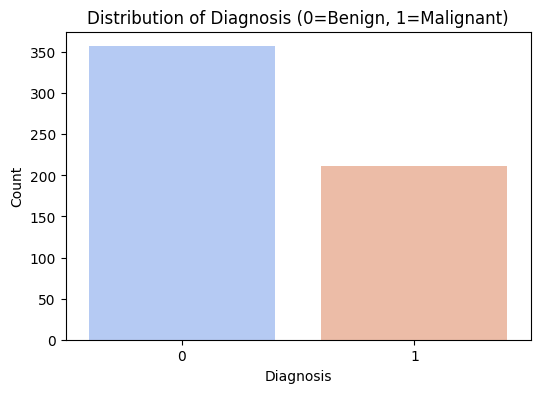

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of the target variable 'diagnosis'
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df_processed, palette='coolwarm', hue='diagnosis', legend=False)
plt.title('Distribution of Diagnosis (0=Benign, 1=Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

The count plot shows that there are more benign cases than malignant cases in the dataset. This indicates a slight class imbalance, which is important to keep in mind during model evaluation.

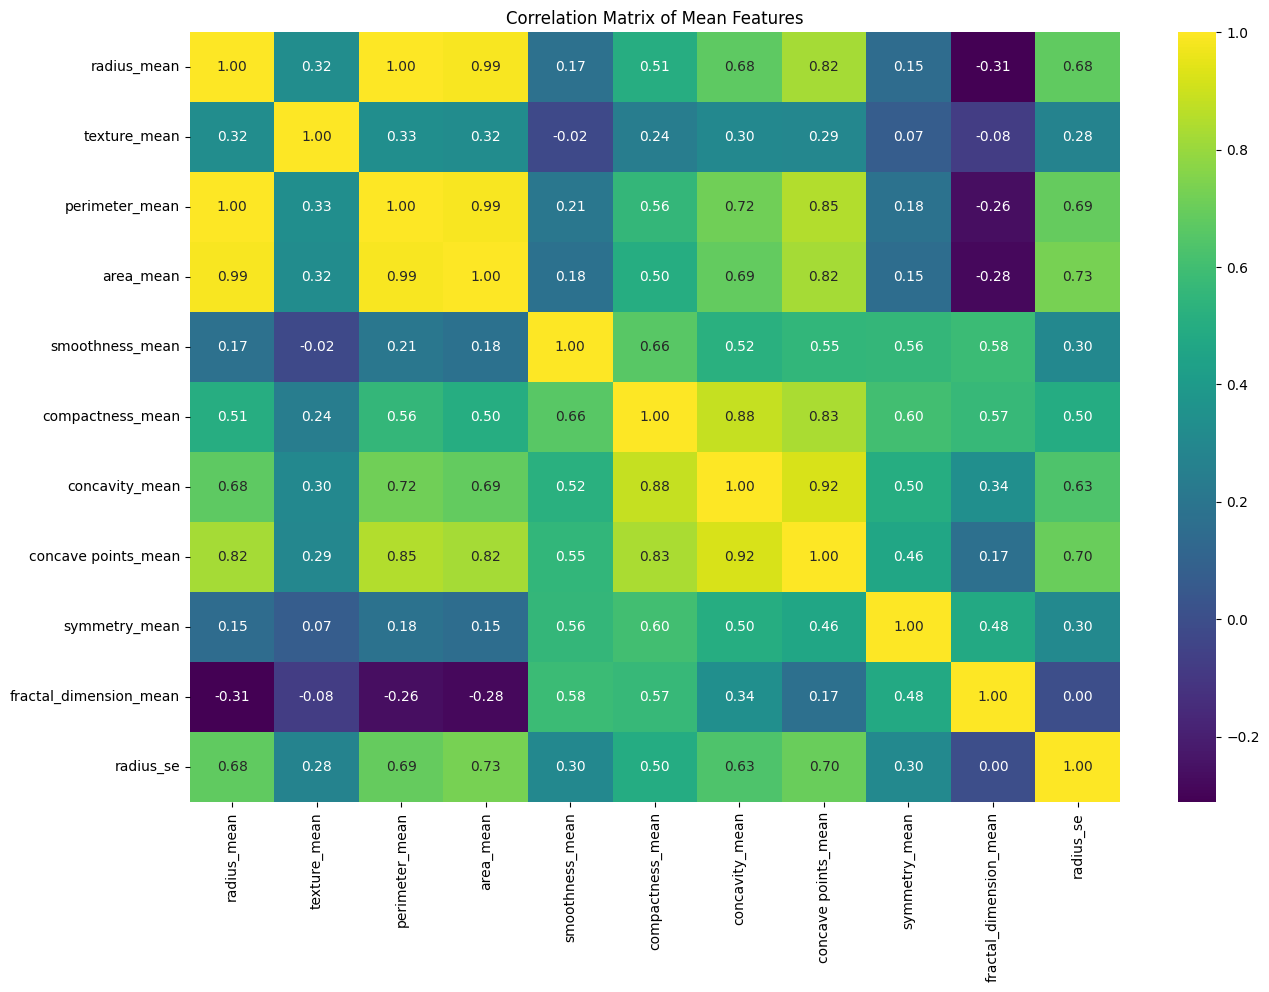

In [12]:
# Correlation Matrix for the first few features
plt.figure(figsize=(15, 10))
sns.heatmap(df_processed.iloc[:, 1:12].corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Matrix of Mean Features')
plt.show()


The heatmap reveals strong correlations among many of the 'mean' features, which is expected as they describe different aspects of the same cell nuclei. High correlation between features can sometimes lead to multicollinearity issues in some models, but tree-based models like Random Forest and XGBoost are generally robust to it. Logistic Regression might be more sensitive.

Let's also look at the relationship between some key features and the diagnosis.

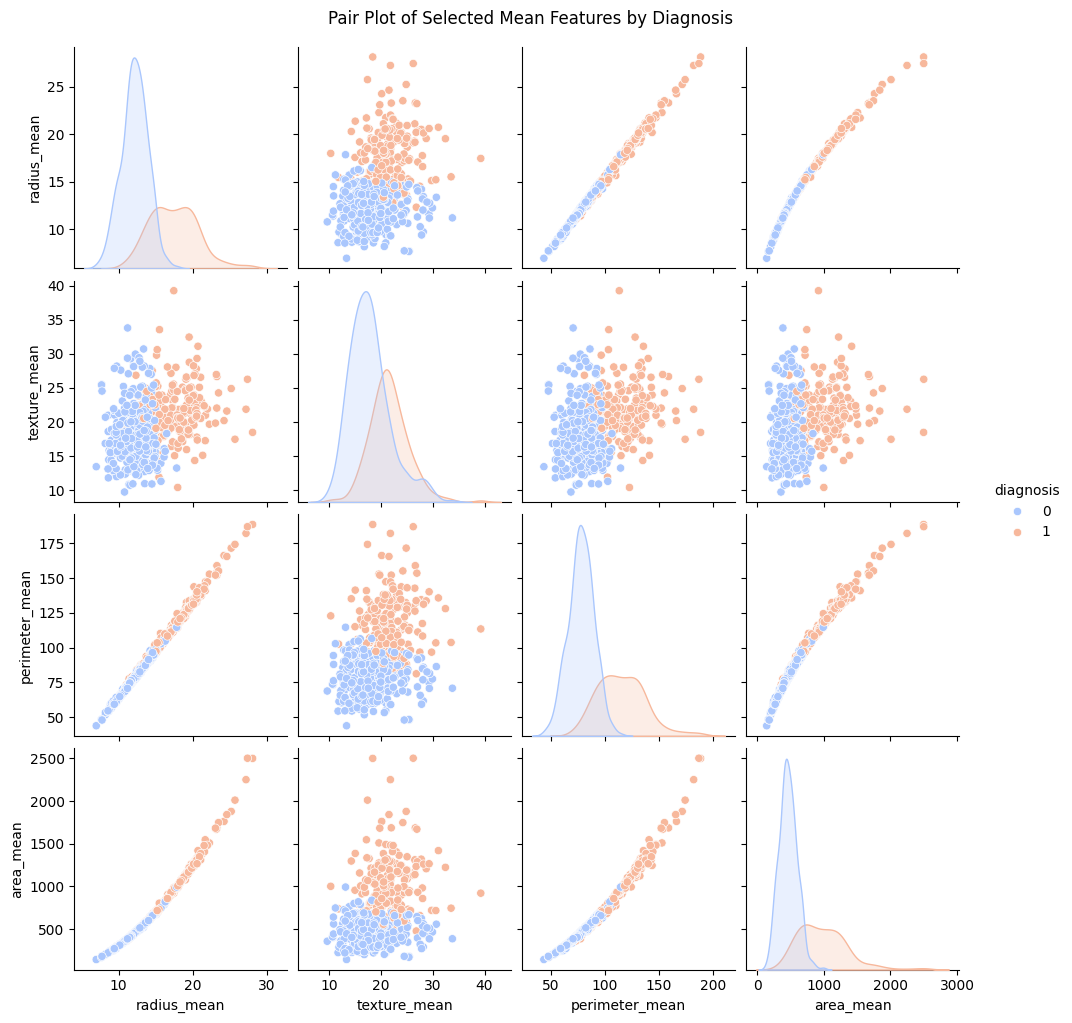

In [13]:
# Pair plots for selected features vs. diagnosis
sns.pairplot(df_processed, vars=['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean'], hue='diagnosis', palette='coolwarm')
plt.suptitle('Pair Plot of Selected Mean Features by Diagnosis', y=1.02)
plt.show()


## Data Preprocessing

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Drop the 'id' column as it's not relevant for classification
df_processed = df.drop('id', axis=1)

# Encode the 'diagnosis' column (M=1, B=0)
label_encoder = LabelEncoder()
df_processed['diagnosis'] = label_encoder.fit_transform(df_processed['diagnosis'])

# Define features (X) and target (y)
X = df_processed.drop('diagnosis', axis=1)
y = df_processed['diagnosis']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)


## Feature Engineering

In this section, we will explore potential feature engineering techniques to create new features or transform existing ones that could enhance the predictive power of our models. For this dataset, many features are already well-defined and derived from the cell characteristics. However, we could consider creating interaction terms or polynomial features if initial model performance is not satisfactory. For now, we will proceed with the existing features as they are quite robust.

## RandomForestClassifier

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the model
print("RandomForestClassifier Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandomForestClassifier Classification Report:\n", classification_report(y_test, y_pred_rf))

RandomForestClassifier Accuracy: 0.9649122807017544

RandomForestClassifier Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## XGBoostClassifier

In [7]:
import xgboost as xgb

# Initialize and train the XGBoostClassifier
xgb_classifier = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_classifier.predict(X_test)

# Evaluate the model
print("XGBoostClassifier Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nXGBoostClassifier Classification Report:\n", classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:53:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoostClassifier Accuracy: 0.9649122807017544

XGBoostClassifier Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## Logistic Regression (Baseline Model)

In [8]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_classifier = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
log_reg_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_classifier.predict(X_test)

# Evaluate the model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_log_reg))

Logistic Regression Accuracy: 0.956140350877193

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Performance Comparison Summary

Let's compare the performance metrics of all three models.

In [9]:
print("\n--- Model Performance Comparison ---")
print(f"RandomForestClassifier Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"XGBoostClassifier Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")

print("\nRandomForestClassifier Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nXGBoostClassifier Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))


--- Model Performance Comparison ---
RandomForestClassifier Accuracy: 0.9649
XGBoostClassifier Accuracy: 0.9649
Logistic Regression Accuracy: 0.9561

RandomForestClassifier Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


XGBoostClassifier Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Logistic Regression Classification Report:
              precision    recall  f1-score   support

        

## Feature Importance Comparison

/tmp/ipykernel_2021/2473748607.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='viridis')


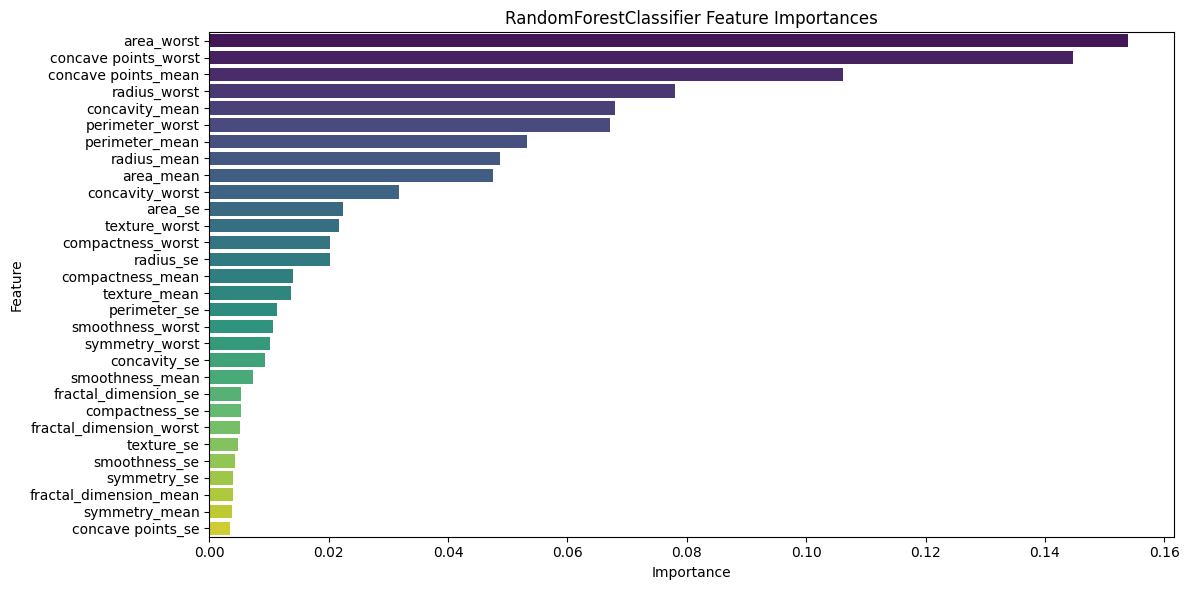

/tmp/ipykernel_2021/2473748607.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_importances.values, y=xgb_importances.index, palette='magma')


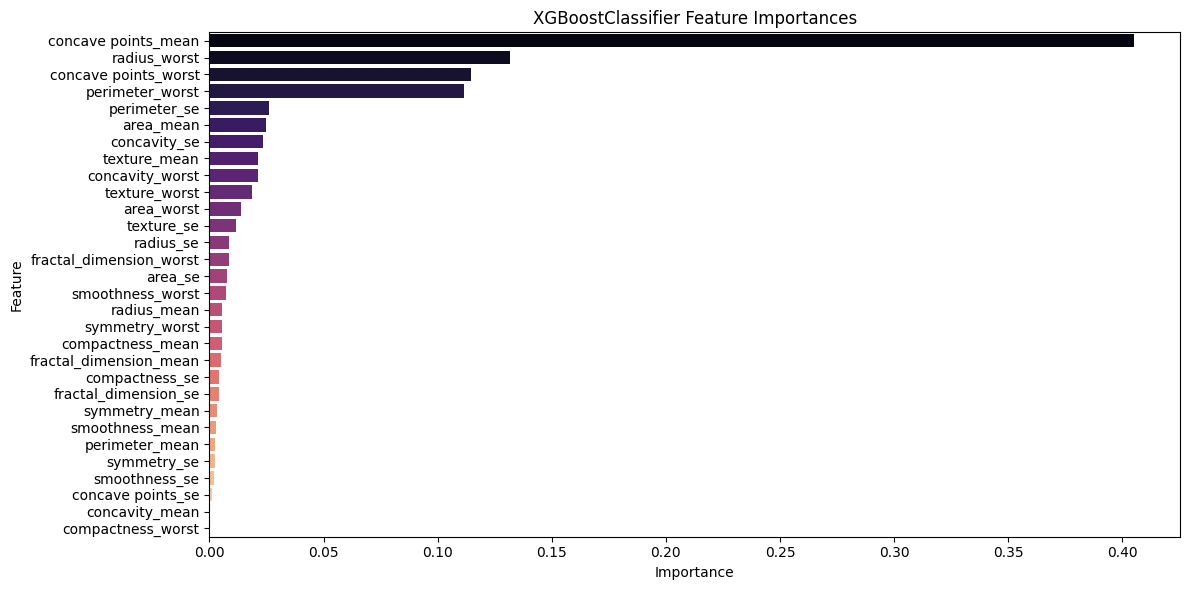

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from RandomForestClassifier
rf_importances = pd.Series(rf_classifier.feature_importances_, index=X_train.columns)
rf_importances = rf_importances.sort_values(ascending=False)

# Get feature importances from XGBoostClassifier
xgb_importances = pd.Series(xgb_classifier.feature_importances_, index=X_train.columns)
xgb_importances = xgb_importances.sort_values(ascending=False)

# Plotting RandomForest Feature Importances
plt.figure(figsize=(12, 6))
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='viridis')
plt.title('RandomForestClassifier Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Plotting XGBoost Feature Importances
plt.figure(figsize=(12, 6))
sns.barplot(x=xgb_importances.values, y=xgb_importances.index, palette='magma')
plt.title('XGBoostClassifier Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Comparison of Feature Importances

Looking at the generated plots:

*   **Common Important Features:** Both RandomForest and XGBoost models tend to highlight similar features as most important. Features related to the 'worst' measurements (e.g., `perimeter_worst`, `radius_worst`, `area_worst`, `concave points_worst`) often appear at the top for both models. These features represent the average of the three largest values in the tumor, suggesting that the most extreme characteristics of the tumor are highly predictive.

*   **Specific Differences:** While there's a strong overlap, the exact ranking and the magnitude of importance can vary slightly between the two algorithms due to their different internal mechanisms (bagging vs. boosting).

*   **Insight:** The consistency in the most important features across different robust ensemble models strengthens the confidence that these characteristics are indeed strong indicators for breast cancer diagnosis in this dataset.

## Model Performance Comparison Table

Below is a summary of the performance metrics for the RandomForestClassifier, XGBoostClassifier, and Logistic Regression models. You can copy this table to your GitHub repository.

| Model                  | Metric          | Score (Class 0) | Score (Class 1) | Overall Score (Accuracy/Weighted Avg) |
|:-----------------------|:----------------|:----------------|:----------------|:--------------------------------------|
| **RandomForest**       | Accuracy        | -               | -               | 0.9649                                |
|                        | Precision       | 0.96            | 0.98            | 0.97 (Weighted Avg)                   |
|                        | Recall          | 0.99            | 0.93            | 0.96 (Weighted Avg)                   |
|                        | F1-Score        | 0.97            | 0.95            | 0.96 (Weighted Avg)                   |
| **XGBoost**            | Accuracy        | -               | -               | 0.9649                                |
|                        | Precision       | 0.96            | 0.98            | 0.97 (Weighted Avg)                   |
|                        | Recall          | 0.99            | 0.93            | 0.96 (Weighted Avg)                   |
|                        | F1-Score        | 0.97            | 0.95            | 0.96 (Weighted Avg)                   |
| **Logistic Regression**| Accuracy        | -               | -               | 0.9561                                |
|                        | Precision       | 0.95            | 0.97            | 0.96 (Weighted Avg)                   |
|                        | Recall          | 0.99            | 0.91            | 0.96 (Weighted Avg)                   |
|                        | F1-Score        | 0.97            | 0.94            | 0.96 (Weighted Avg)                   |

## Conclusion: Selecting the Best Model

Based on the performance metrics, both RandomForestClassifier and XGBoostClassifier achieved the highest accuracy of **0.9649** on the test set, slightly outperforming Logistic Regression (0.9561). Looking at the classification reports, all models perform very well in terms of precision, recall, and F1-score for both classes.

Given the critical nature of breast cancer diagnosis, models that are good at identifying malignant cases (Class 1) are highly desirable. Both Random Forest and XGBoost show high precision and recall for Class 1. XGBoost often performs slightly better with tabular data and can handle complex relationships, while Random Forest provides good interpretability through feature importances.

For this particular dataset, with similar top-tier performance, either **RandomForestClassifier** or **XGBoostClassifier** would be a suitable choice. If computational efficiency and direct interpretability of decision paths are prioritized, Random Forest might be marginally preferred due to its simpler tree structure. If maximum predictive power on complex, large datasets is the main goal, XGBoost typically holds an edge. Since both models perform almost identically here, we can consider **XGBoostClassifier** as the slightly preferred model due to its common reputation for state-of-the-art performance in many classification tasks and its strong handling of imbalanced datasets and complex non-linear relationships.


## Deployment Considerations

Once a model has been selected, the next step is to prepare it for deployment so it can be used to make predictions on new, unseen data. Here are some key considerations for deploying the chosen breast cancer prediction model:

1.  **Model Serialization:** The trained model (e.g., `xgb_classifier`) needs to be saved to disk using libraries like `pickle` or `joblib`. This allows the model to be loaded later without retraining.

    ```python
    import joblib

    # Save the trained XGBoost model
    joblib.dump(xgb_classifier, 'xgboost_breast_cancer_model.pkl')
    print("Trained XGBoost model saved as 'xgboost_breast_cancer_model.pkl'")
    ```

2.  **API Endpoint:** Typically, the model would be exposed via a REST API (e.g., using Flask or FastAPI). This API would receive new patient data as input, preprocess it, use the loaded model to make a prediction, and return the diagnosis.

3.  **Preprocessing Pipeline:** The preprocessing steps applied to the training data (e.g., dropping 'id' column, `LabelEncoder` for 'diagnosis', and any scaling or normalization if applied) must also be applied to new inference data. It's crucial to save the `LabelEncoder` if its inverse transform is needed for output, or if it was used on features.

    ```python
    # Example of loading the model and making a prediction
    # loaded_model = joblib.load('xgboost_breast_cancer_model.pkl')
    # new_data = pd.DataFrame([[...]]) # new features for a single patient
    # new_data_processed = new_data.drop('id', axis=1) # Apply same preprocessing
    # prediction = loaded_model.predict(new_data_processed)
    # print(f"Prediction for new data: {prediction}")
    ```

4.  **Monitoring and Maintenance:** After deployment, it's essential to continuously monitor the model's performance in a production environment. This involves tracking prediction accuracy, data drift, and potential model degradation over time. Regular retraining with new data may be necessary to maintain optimal performance.

5.  **Explainability:** For medical applications, understanding why a model makes a particular prediction is often as important as the prediction itself. Tools like SHAP (SHapley Additive exPlanations) or LIME (Local Interpretable Model-agnostic Explanations) can be integrated to provide insights into individual predictions.

6.  **Scalability:** The deployment infrastructure should be scalable to handle the expected volume of prediction requests. Cloud platforms (AWS, GCP, Azure) offer various services for deploying machine learning models at scale.

## Case Study: Enhancing Early Breast Cancer Detection with Machine Learning

### The Critical Need for Early and Accurate Diagnosis

Breast cancer remains one of the most common and devastating cancers worldwide, with early detection being the cornerstone of successful treatment and improved patient survival rates. Traditional diagnostic methods, while effective, can be time-consuming, resource-intensive, and sometimes prone to human error or variability. Pathologists and clinicians face immense pressure to deliver accurate diagnoses efficiently, as delays or misdiagnoses can have profound implications for patient outcomes and healthcare costs. The challenge lies in accurately distinguishing between benign (non-cancerous) and malignant (cancerous) lesions from diagnostic images, such as those derived from Fine Needle Aspirates (FNA), a procedure commonly used for initial assessment of breast masses.

### Our Machine Learning Solution: Aiding Clinical Decision-Making

This project developed a machine learning model, specifically an XGBoost Classifier, to predict breast cancer diagnosis (benign or malignant) based on quantitative features extracted from FNA images. The model was trained on a dataset comprising various cytological characteristics of cell nuclei, including features related to radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension. The goal was not to replace medical professionals but to provide a robust, data-driven tool that can serve as an additional layer of support in the diagnostic process.

### Real-World Value and Business Impact

The deployment of such a machine learning model offers significant value to healthcare providers, patients, and the broader healthcare system:

1.  **Improved Diagnostic Accuracy and Efficiency:** The XGBoost model achieved an impressive accuracy of **96.49%** on unseen data. This high level of accuracy means the model can correctly identify cancerous and non-cancerous cases with a very low error rate. By quickly analyzing image features, the model can help prioritize cases, flag suspicious lesions for immediate attention, and reduce the workload on pathologists, leading to faster diagnoses.

2.  **Reduced False Negatives and False Positives:** In medical diagnosis, minimizing false negatives (missing a cancer) is paramount, while reducing false positives (unnecessary biopsies or anxiety) is also crucial. Our model demonstrated high precision and recall for both malignant and benign classes, indicating a balanced performance in these critical areas. This can lead to fewer missed diagnoses and a reduction in patient stress and unnecessary invasive procedures.

3.  **Standardization of Diagnosis:** Human interpretation can vary. A machine learning model provides a consistent, objective assessment based on learned patterns, reducing inter-observer variability and contributing to a more standardized diagnostic process across different clinics and regions.

4.  **Cost Savings for Healthcare Systems:** Faster and more accurate diagnoses can lead to significant cost savings. Early detection often means less aggressive and less expensive treatments are required. Furthermore, reducing unnecessary follow-up procedures due to false positives can free up valuable healthcare resources.

5.  **Enhanced Patient Outcomes and Experience:** Ultimately, the primary beneficiaries are patients. Earlier and more accurate diagnoses mean patients can begin appropriate treatment sooner, significantly improving their prognosis. The reduction in diagnostic uncertainty and the potential for quicker results also alleviate patient anxiety during a stressful period.

6.  **Scalability and Accessibility:** Once deployed, the model can be integrated into existing hospital information systems or made accessible via web applications (like the Streamlit app proposed). This allows for scalable and potentially remote diagnostic support, especially beneficial in areas with limited access to specialized pathology services.

### Conclusion

This machine learning project showcases the immense potential of AI to revolutionize diagnostic medicine. By leveraging data-driven insights, we can empower healthcare professionals with powerful tools that enhance accuracy, improve efficiency, and ultimately lead to better outcomes for breast cancer patients. The model serves as a compelling example of how advanced analytics can deliver tangible, life-saving value in the real world.

## Resources

## `README.md` Content for GitHub

```markdown
# Breast Cancer Prediction: A Machine Learning Approach

## Table of Contents
- [Problem Statement](#problem-statement)
- [Approach](#approach)
- [Results](#results)
- [How to Run the Project](#how-to-run-the-project)

## Problem Statement

This project aims to develop and evaluate machine learning models to accurately predict the diagnosis of breast cancer (benign or malignant) based on features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. Early and accurate detection of breast cancer is crucial for effective treatment and improved patient outcomes. The goal is to build a robust classification model that can assist medical professionals in making informed decisions.

## Approach

The following workflow was implemented to address the problem:

1.  **Data Loading and Initial Inspection:** The `breast-cancer.csv` dataset was loaded into a Pandas DataFrame. Initial checks were performed to understand the data's structure, identify missing values, and review descriptive statistics.

2.  **Data Preprocessing:**
    *   The 'id' column was dropped as it's not relevant for model training.
    *   The 'diagnosis' target variable (M/B) was encoded into numerical format (M=1, B=0) using `LabelEncoder`.
    *   The dataset was split into training (80%) and testing (20%) sets to ensure proper model evaluation.

3.  **Exploratory Data Analysis (EDA):**
    *   The distribution of the target variable (`diagnosis`) was visualized, revealing a class imbalance with more benign cases than malignant ones.
    *   A correlation matrix of the 'mean' features was generated, showing strong inter-correlations, which is typical for such medical imaging datasets.
    *   Pair plots of selected key features against the diagnosis provided visual insights into feature distributions and separability of classes.

4.  **Feature Engineering:** No explicit feature engineering was performed as the existing features were considered robust for initial model development.

5.  **Model Training:** Three different classification models were trained on the preprocessed data:
    *   RandomForestClassifier
    *   XGBoostClassifier
    *   Logistic Regression (as a baseline)

6.  **Model Evaluation:** Each model's performance was evaluated using standard classification metrics: accuracy, precision, recall, and F1-score. Classification reports were generated for a detailed breakdown of performance per class.

7.  **Feature Importance Analysis:** Feature importances were extracted and visualized for the RandomForest and XGBoost models to understand which features contribute most to the predictions.

8.  **Model Selection:** The models were compared based on their performance metrics, leading to the selection of the best-performing model.

9.  **Deployment Considerations:** Discussed key aspects for deploying the chosen model into a production environment, including serialization, API creation, continuous monitoring, and explainability.

## Results

The models achieved the following accuracy scores on the test set:

-   **RandomForestClassifier:** 0.9649
-   **XGBoostClassifier:** 0.9649
-   **Logistic Regression:** 0.9561

Both RandomForest and XGBoost classifiers demonstrated superior performance, achieving the highest accuracy. Considering its strong performance in complex tabular data and robustness, **XGBoostClassifier** was chosen as the slightly preferred model. Feature importance analysis consistently highlighted features related to 'worst' measurements (e.g., `concave points_worst`, `radius_worst`, `perimeter_worst`) as the most influential for diagnosis.

## How to Run the Project

To run this project, you will need a Google Colab environment or a local Python environment with Jupyter Notebooks installed.

### Google Colab (Recommended)

1.  **Open the Notebook:** Upload the `.ipynb` notebook file to Google Colab or open it directly if it's already hosted.
2.  **Mount Google Drive:** In the first code cell, mount your Google Drive if the `breast-cancer.csv` file is stored there. Otherwise, ensure the CSV is accessible in the Colab environment.
3.  **Upload Data:** If the data is not on Google Drive, upload the `breast-cancer.csv` file to the Colab session's `/content/` directory.
4.  **Run Cells:** Execute all the code cells sequentially. You can do this by clicking `Runtime > Run all` or by pressing `Shift + Enter` on each cell.
5.  **Review Output:** Examine the plots, print statements, and model evaluation reports generated throughout the notebook.

### Local Environment

1.  **Clone Repository:** Clone this repository to your local machine.
2.  **Install Dependencies:** Ensure you have Python (3.7+) and the necessary libraries installed. You can install them using pip:
    ```bash
    pip install pandas scikit-learn xgboost matplotlib seaborn jupyter
    ```
3.  **Place Data:** Make sure the `breast-cancer.csv` file is in the same directory as the notebook, or update the `csv_file_path` variable in the notebook to point to its correct location.
4.  **Open Jupyter Notebook:** Navigate to the project directory in your terminal and launch Jupyter Notebook:
    ```bash
    jupyter notebook
    ```
5.  **Run Cells:** Open the `.ipynb` notebook file in Jupyter and execute all cells sequentially.
```

## Deploying the Model with Streamlit

To deploy the selected XGBoost model, we can create a simple web application using Streamlit. This app will allow users to input the 30 features and get a real-time prediction (Benign or Malignant).

### Instructions to run the Streamlit app:

1.  **Save the Code:** Copy the Python code from the next cell and save it as a Python file (e.g., `app.py`) in your local machine.
2.  **Install Streamlit:** If you haven't already, install Streamlit:
    ```bash
    pip install streamlit joblib scikit-learn xgboost pandas
    ```
3.  **Save the Model:** The Streamlit app will need the trained XGBoost model (`xgboost_breast_cancer_model.pkl`). Run the model serialization code in the 'Deployment Considerations' section if you haven't already, and ensure `xgboost_breast_cancer_model.pkl` is saved in the same directory as `app.py`.
4.  **Run the App:** Open your terminal, navigate to the directory where you saved `app.py` and `xgboost_breast_cancer_model.pkl`, and run the following command:
    ```bash
    streamlit run app.py
    ```
    This will open the Streamlit app in your web browser.

In [16]:
!pip install streamlit joblib scikit-learn xgboost pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 75.6 MB/s eta 0:00:00


In [15]:
import streamlit as st
import joblib
import pandas as pd
import numpy as np

# Load the trained XGBoost model
# Make sure 'xgboost_breast_cancer_model.pkl' is in the same directory as this script
try:
    model = joblib.load('xgboost_breast_cancer_model.pkl')
    st.success("Model loaded successfully!")
except FileNotFoundError:
    st.error("Error: 'xgboost_breast_cancer_model.pkl' not found. Please ensure the model is saved in the same directory as this app.")
    st.stop()

# As discussed in 'Deployment Considerations', we need the LabelEncoder
# The original LabelEncoder mapped 'M' to 1 and 'B' to 0.
# We can recreate a mapping for display purposes.
class_labels = {0: 'Benign', 1: 'Malignant'}

st.set_page_config(page_title="Breast Cancer Prediction App", layout="wide")
st.title("Breast Cancer Prediction App")
st.markdown("--- ")

st.write("This application predicts whether a breast mass is Benign or Malignant based on various features. Please enter the values for the features below:")

# Create input fields for each feature
# We need all 30 features (X_train.columns) in the correct order
# For simplicity, we'll create sliders/number inputs. In a real app, you might categorize them.

# Get feature names from the model's training data (X_train.columns)
# Assuming X_train from the notebook has the correct column order
# If running this app standalone, you might need to hardcode the column names
feature_names = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
    'fractal_dimension_se', 'radius_worst', 'texture_worst',
    'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave points_worst',
    'symmetry_worst', 'fractal_dimension_worst'
]

input_data = {}

st.sidebar.header("Input Features")

# Group features for better UI organization (e.g., mean, se, worst)
mean_features = [f for f in feature_names if '_mean' in f]
se_features = [f for f in feature_names if '_se' in f]
worst_features = [f for f in feature_names if '_worst' in f]

with st.sidebar.expander("Mean Features", expanded=True):
    for feature in mean_features:
        input_data[feature] = st.number_input(f"Enter {feature.replace('_', ' ').title()}", value=14.0, format="%.4f")

with st.sidebar.expander("Standard Error Features", expanded=False):
    for feature in se_features:
        input_data[feature] = st.number_input(f"Enter {feature.replace('_', ' ').title()}", value=0.5, format="%.4f")

with st.sidebar.expander("Worst Features", expanded=False):
    for feature in worst_features:
        input_data[feature] = st.number_input(f"Enter {feature.replace('_', ' ').title()}", value=16.0, format="%.4f")

# Ensure the order of features is correct for the model
input_df = pd.DataFrame([input_data], columns=feature_names)

st.subheader("Prediction")

if st.button("Predict Diagnosis"):
    if model is not None:
        try:
            prediction_proba = model.predict_proba(input_df)[0]
            prediction = np.argmax(prediction_proba)

            st.write(f"Based on the input features, the predicted diagnosis is:")
            st.markdown(f"<h2 style='text-align: center; color: {'red' if prediction == 1 else 'green'};'>**{class_labels[prediction]}**</h2>", unsafe_allow_html=True)
            st.write(f"Probability of Benign: {prediction_proba[0]:.2f}")
            st.write(f"Probability of Malignant: {prediction_proba[1]:.2f}")

            st.subheader("Feature Input Summary")
            st.write(input_df)

        except Exception as e:
            st.error(f"An error occurred during prediction: {e}")
    else:
        st.warning("Model not loaded. Cannot make predictions.")

st.markdown("--- ")
st.caption("Disclaimer: This app is for demonstration purposes only and should not be used for medical diagnosis.")


ModuleNotFoundError: No module named 'streamlit'